In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv(r"../data/feature_engineered_data.csv")
df.shape

(99999, 28)

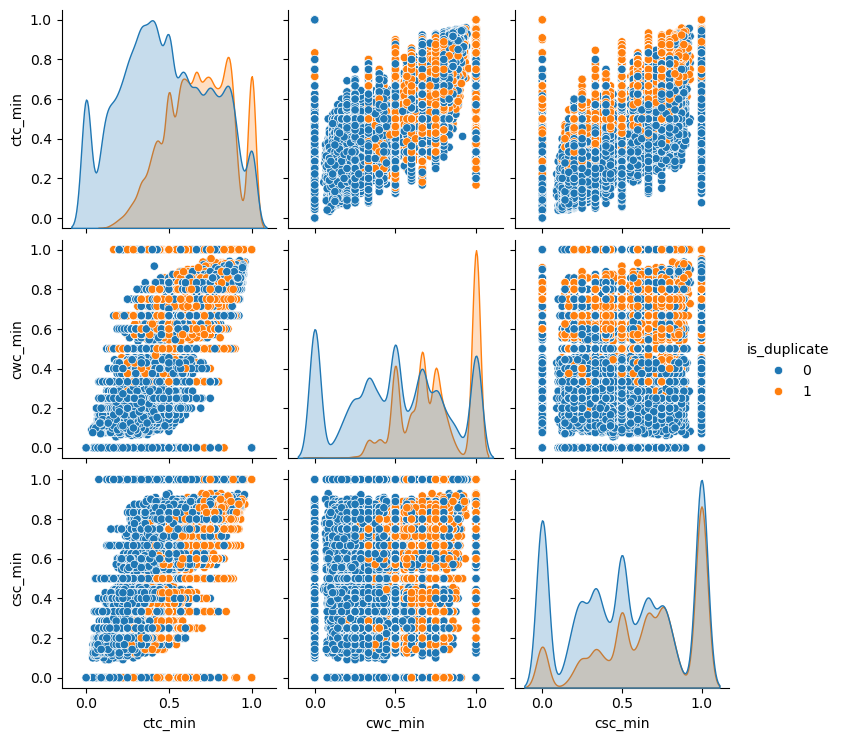

In [18]:
sns.pairplot(df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate')

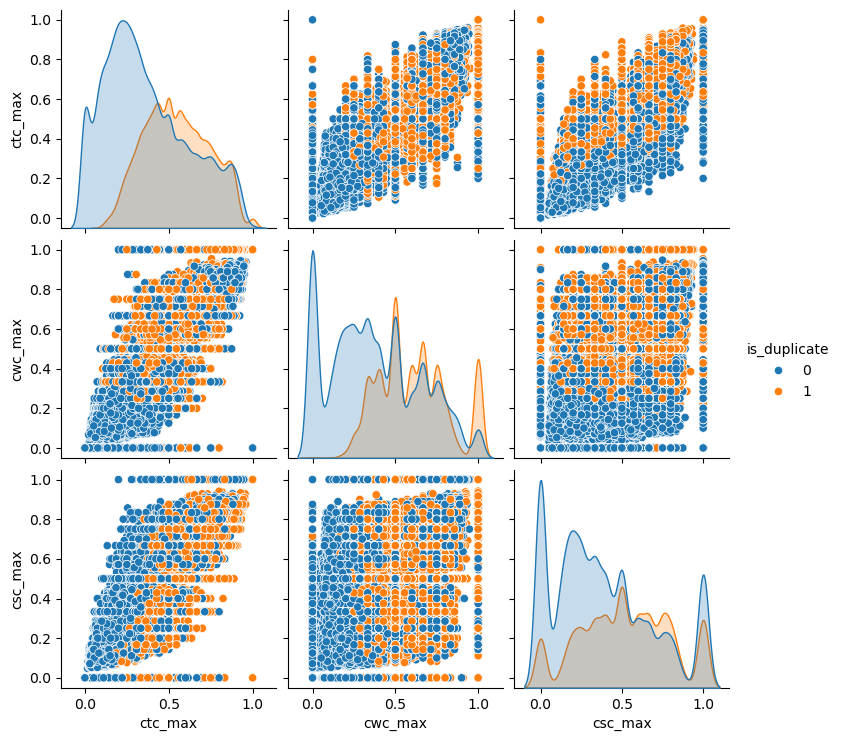

In [19]:
sns.pairplot(df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']],hue='is_duplicate')

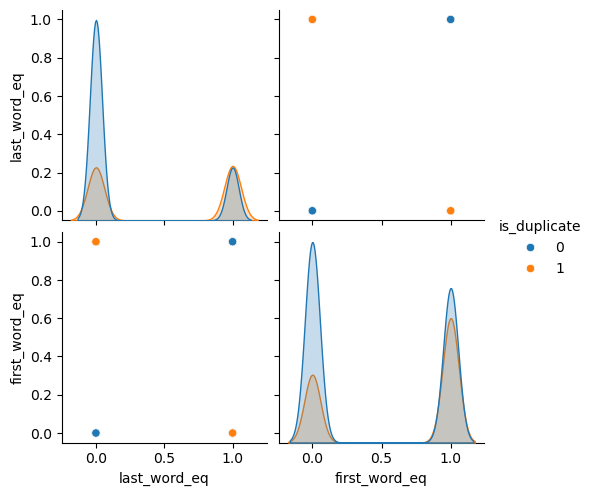

In [20]:
sns.pairplot(df[['last_word_eq', 'first_word_eq', 'is_duplicate']],hue='is_duplicate')

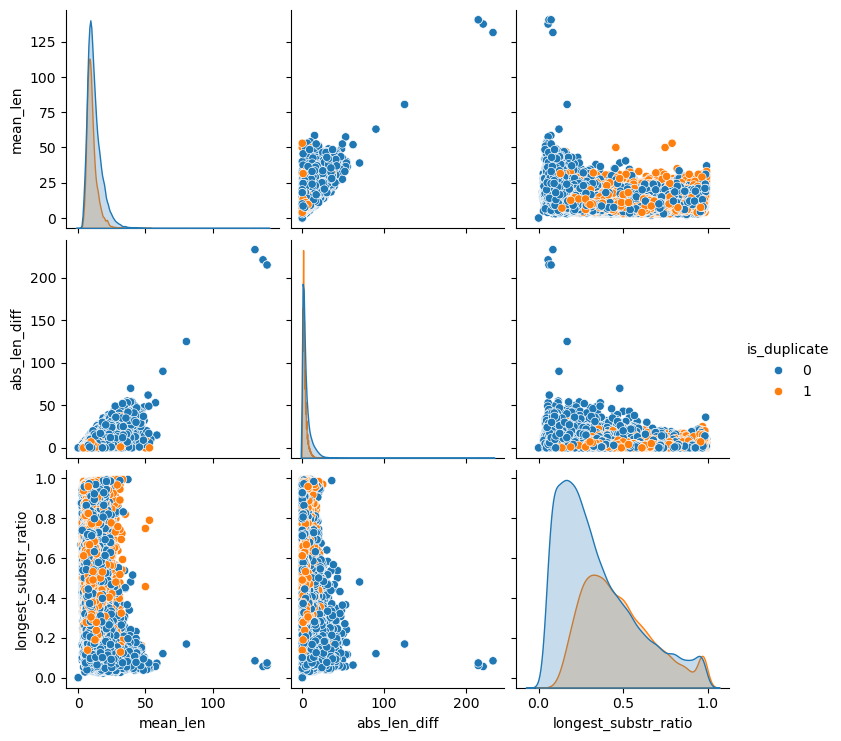

In [21]:
sns.pairplot(df[['mean_len', 'abs_len_diff','longest_substr_ratio', 'is_duplicate']],hue='is_duplicate')


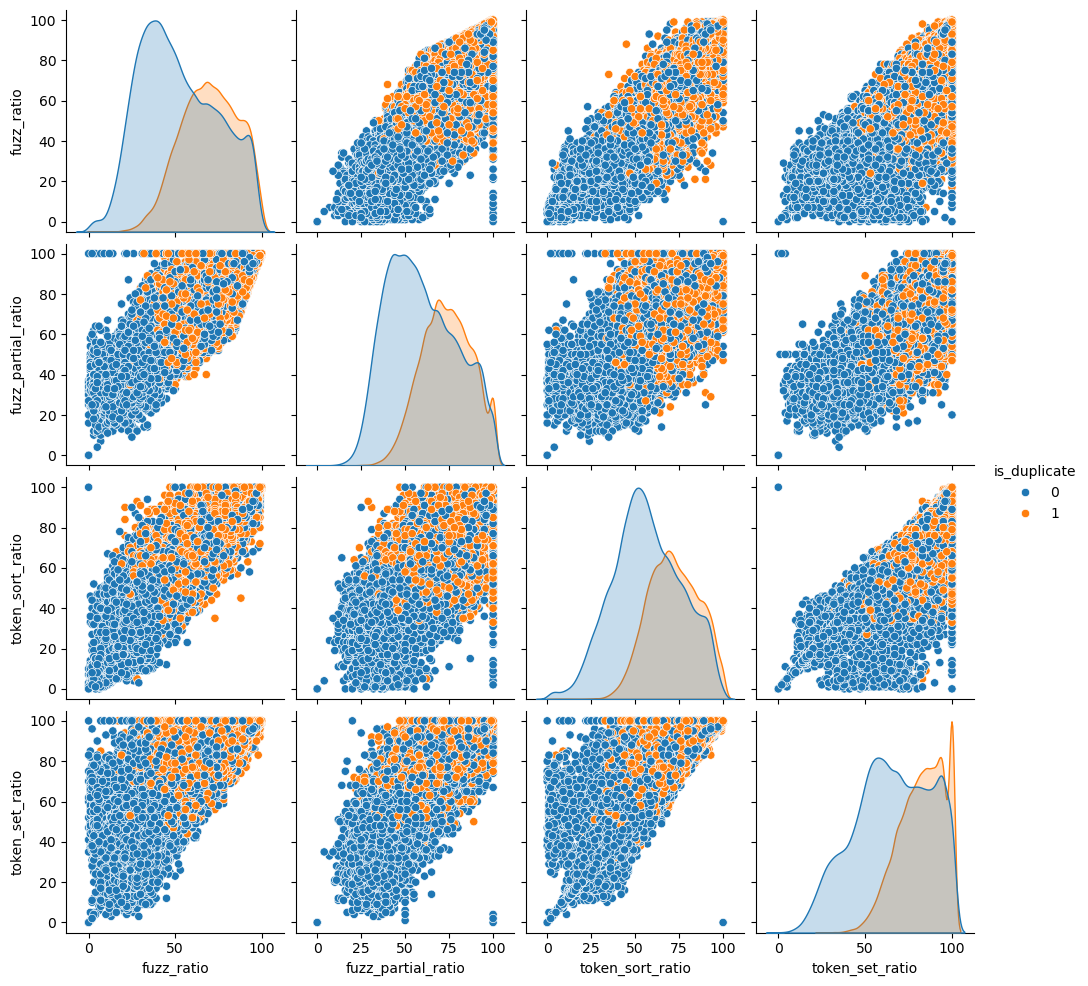

In [22]:
sns.pairplot(df[['fuzz_ratio', 'fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')

In [23]:
# Using TSNE for Dimentionality reduction for 15 Features(Generated after cleaning the data) to 3 dimention

from sklearn.preprocessing import MinMaxScaler

X = MinMaxScaler().fit_transform(df[['cwc_min', 'cwc_max', 'csc_min', 'csc_max' , 'ctc_min' , 'ctc_max' , 'last_word_eq', 'first_word_eq' , 'abs_len_diff' , 'mean_len' , 'token_set_ratio' , 'token_sort_ratio' ,  'fuzz_ratio' , 'fuzz_partial_ratio' , 'longest_substr_ratio']])
y = df['is_duplicate'].values

In [24]:
from sklearn.manifold import TSNE

tsne2d = TSNE(
    n_components=2,
    init='random', # pca
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(X)

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 99999 samples in 0.334s...
[t-SNE] Computed neighbors for 99999 samples in 45.486s...
[t-SNE] Computed conditional probabilities for sample 1000 / 99999
[t-SNE] Computed conditional probabilities for sample 2000 / 99999
[t-SNE] Computed conditional probabilities for sample 3000 / 99999
[t-SNE] Computed conditional probabilities for sample 4000 / 99999
[t-SNE] Computed conditional probabilities for sample 5000 / 99999
[t-SNE] Computed conditional probabilities for sample 6000 / 99999
[t-SNE] Computed conditional probabilities for sample 7000 / 99999
[t-SNE] Computed conditional probabilities for sample 8000 / 99999
[t-SNE] Computed conditional probabilities for sample 9000 / 99999
[t-SNE] Computed conditional probabilities for sample 10000 / 99999
[t-SNE] Computed conditional probabilities for sample 11000 / 99999
[t-SNE] Computed conditional probabilities for sample 12000 / 99999
[t-SNE] Computed conditional probabilities for sa

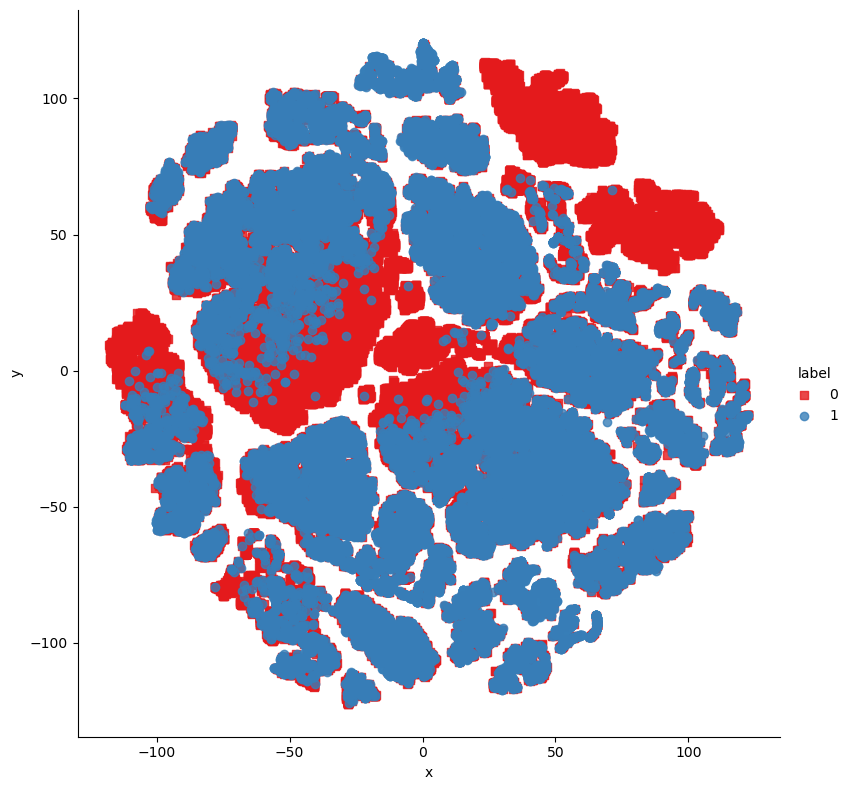

In [25]:
x_df = pd.DataFrame({'x':tsne2d[:,0], 'y':tsne2d[:,1] ,'label':y})

# draw the plot in appropriate place in the grid
sns.lmplot(data=x_df, x='x', y='y', hue='label', fit_reg=False, height=8,palette="Set1",markers=['s','o'])